In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets, metrics, svm
from sklearn.datasets import fetch_openml


In [2]:
# Iris-Datensatz laden
iris = datasets.load_iris()

X = iris['data'][:, :2]  
y = np.where(iris['target'] == 0, 1, -1)

In [3]:
# Linear Model + Grad Linear Model
def linear_model(theta):
    def res(x):
        return theta[0] + np.sum(theta[1:] * x, axis=1)
    return res

def grad_linear_model(x):
    N, k = x.shape
    G = np.ones((N, k + 1))
    G[:, 1:] = x
    return G

In [4]:
# Hinge Loss Function + Grad Hinge Loss
def hinge_cost_function(x, y, model_fct, C=1):
    def cost_fct(theta):
        model = model_fct(theta)
        
        margins = 1 - y * model(x)
        hinge_loss = np.sum(np.maximum(0, margins))
        reg_term = 0.5 * np.sum(theta[1:] ** 2)
        
        return reg_term + C * hinge_loss
        
    return cost_fct

def grad_hinge_loss(x, y, theta, model_fct, model_grad_fct, C=1):
    model = model_fct(theta)
    model_x = model(x)
    
    margins = 1 - y * model_x 
    grad_model = model_grad_fct(x) 
    
    mask = margins > 0  
    
    hinge_grad = np.sum((-y[mask].reshape(-1, 1)) * grad_model[mask],axis=0)
    
    reg_grad = np.zeros_like(theta)
    reg_grad[1:] = theta[1:]  
    
    grad_J = reg_grad + C * hinge_grad
    
    return grad_J

In [5]:
# Theta Update und Gradient Descent
def update_theta(x, y, theta, alpha, cost_grad, model_fct, model_grad_fct):
    grad = cost_grad(x,y,theta,model_fct,model_grad_fct)
    t = theta - alpha*grad
    return t
    
def gradient_descent(x, y, num_parameters, model_fct, model_grad_fct, cost_fct, cost_grad_fct, epsilon=1E-4, alpha=0.0001, verbose=False, max_iterations=10000):
    k = 0
    theta = np.random.rand(num_parameters)
    
    grad_norm = np.linalg.norm(cost_grad_fct(x,y,theta,model_fct,model_grad_fct))

    cost = cost_fct(x,y,model_fct)
    
    theta_hist = [theta]
    cost_hist = [cost(theta)]
    
    while grad_norm > epsilon and k < max_iterations:
        theta = update_theta(x,y,theta,alpha,cost_grad_fct,model_fct,model_grad_fct)
        theta_hist.append(theta)
        cost_hist.append(cost(theta))
        grad_norm = np.linalg.norm(cost_grad_fct(x,y,theta,model_fct,model_grad_fct))
        k += 1

    if verbose:
        print(f'final result\n\tcost: {cost(theta)}\n\t$\\theta$: {theta}\n\tnumber of iterations: {k}\n\tgradient norm: {grad_norm}')
    return cost_hist,theta_hist


final result
	cost: 6.013417756388476
	$\theta$: [ 4.69143586 -2.3539287   2.52625529]
	number of iterations: 50000
	gradient norm: 18.42499660667683


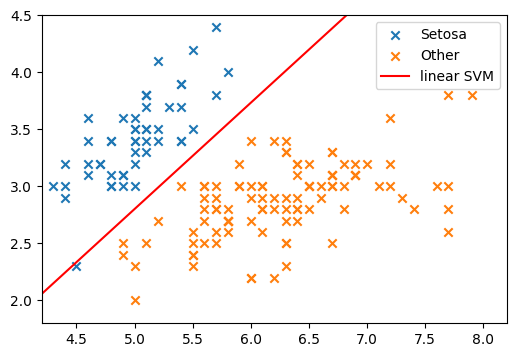

In [6]:
num_parameters = X.shape[1] + 1
C = 0.01

cost_hist, theta_hist = gradient_descent(
    X, y, num_parameters,
    model_fct=linear_model,
    model_grad_fct=grad_linear_model,
    cost_fct=lambda x,y,mf: hinge_cost_function(x, y, mf, C=C),
    cost_grad_fct=grad_hinge_loss,
    epsilon=1e-4,
    alpha=0.001,
    verbose=True,
    max_iterations=50000
)

theta_final = theta_hist[-1]

X_pos = X[y == 1]   # Setosa
X_neg = X[y == -1]  # Other

plt.figure(figsize=(6, 4))
plt.scatter(X_pos[:, 0], X_pos[:, 1], marker='x', label='Setosa')
plt.scatter(X_neg[:, 0], X_neg[:, 1], marker='x', label='Other')

# Entscheidungsgrenze: h_theta(x) = theta_0 + theta_1*x1 + theta_2*x2 = 0
x1_vals = np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 200)
x2_vals = -(theta_final[0] + theta_final[1]*x1_vals)/theta_final[2]
plt.plot(x1_vals, x2_vals, label='linear SVM', color='red')

#Damit es ansatzweise dem beispiel ähnelt
plt.xlim(4.2, 8.2)
plt.ylim(1.8, 4.5)
plt.legend()
plt.show()

Shape von X: (70000, 784)
Shape von y: (70000,)


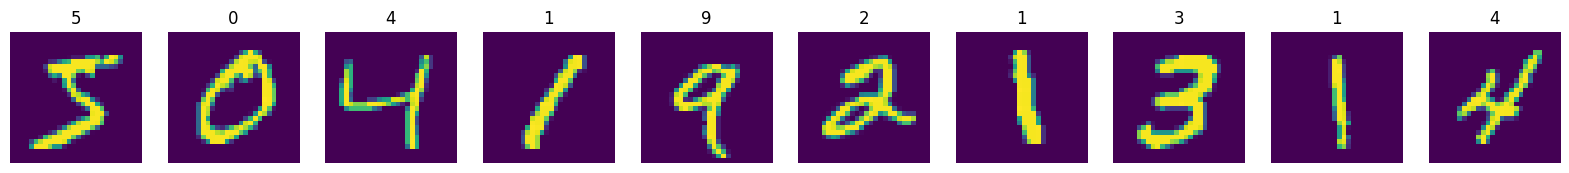

In [7]:
mnist = fetch_openml("mnist_784", version=1)
X = mnist.data
y = mnist.target.astype(int)  # Labels als int
print("Shape von X:", X.shape)  
print("Shape von y:", y.shape) 

plt.figure(figsize=(20, 4))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(X.iloc[i].values.reshape(28,28))
    plt.axis('off')
    plt.title(y[i])
plt.show()


In [8]:
x_val = X[-10000:]
y_val = y[-10000:]

X_train_full = X[:-10000]
y_train_full = y[:-10000]

def get_train_data(n):
    return X_train_full[:n], y_train_full[:n]


Accuracy: 0.8758

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       980
           1       0.94      0.97      0.95      1135
           2       0.87      0.90      0.88      1032
           3       0.87      0.78      0.82      1010
           4       0.87      0.88      0.88       982
           5       0.76      0.83      0.80       892
           6       0.93      0.91      0.92       958
           7       0.89      0.88      0.88      1028
           8       0.87      0.79      0.83       974
           9       0.80      0.84      0.82      1009

    accuracy                           0.88     10000
   macro avg       0.88      0.87      0.87     10000
weighted avg       0.88      0.88      0.88     10000


Confusion Matrix:
[[ 948    0    5    1    4    8    8    3    2    1]
 [   0 1100    2    1    0    2    2    3   24    1]
 [  11   14  924   13   10    4   19   18   18    1]
 [   3    6   37  785 

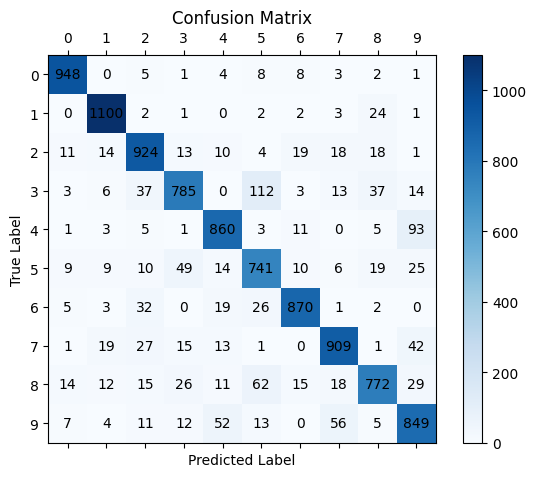

In [9]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X_train, y_train = get_train_data(1000) 

svm_clf = SVC(kernel='linear', C=1.0)
svm_clf.fit(X_train, y_train)

y_val_pred = svm_clf.predict(x_val)

# Accuracy
acc = accuracy_score(y_val, y_val_pred)
print("Accuracy:", acc)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(7, 5))
plt.matshow(cm, fignum=1, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Achsenbeschriftung 0-9
classes = np.arange(10)
plt.xticks(classes, classes)
plt.yticks(classes, classes)

# Zahlen in den Zellen anzeigen
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center')
        
plt.show()

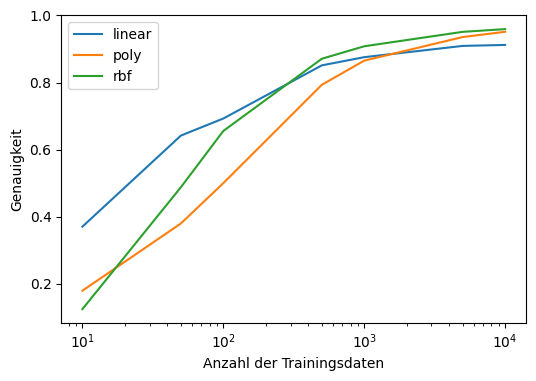

In [10]:
train_sizes = [10, 50, 100, 500, 1000, 5000, 10000] 
kernels = ['linear', 'poly', 'rbf']

accuracy_results = {k: [] for k in kernels}

for kernel in kernels:
    for size in train_sizes:
        X_train, y_train = get_train_data(size)
        svm_clf = SVC(kernel=kernel, C=1.0)
        svm_clf.fit(X_train, y_train)
        y_val_pred = svm_clf.predict(x_val)
        acc = accuracy_score(y_val, y_val_pred)
        accuracy_results[kernel].append(acc)

plt.figure(figsize=(6, 4))

for kernel in kernels:
    plt.plot(train_sizes, accuracy_results[kernel], label=kernel)

plt.xscale('log')
plt.xlabel("Anzahl der Trainingsdaten")
plt.ylabel("Genauigkeit")
plt.legend()
plt.show()

# Linear: Genauigkeit steigt schnell mit der Anzahl der Daten, kann aber eventuell Ausreißer schlecht klassifizieren.
# Poly: braucht eine gewisse Anzahl an Daten, um hohe Genauigkeit zu erreichen, kann aber gut overfitten → sehr hohe Genauigkeit auf Trainingsdaten.
# RBF: bei schwer linear trennbaren Problemen kann gute Genauigkeit erreicht werden, ist aber anfälliger für Overfitting bei kleinen Trainingsmengen.

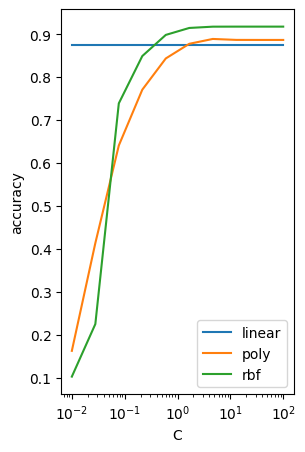

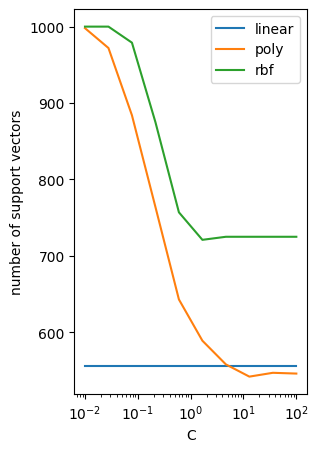

In [11]:
X_train, y_train = get_train_data(1000)  


C_values = np.logspace(-2, 2, 10) 
kernels = ['linear', 'poly', 'rbf']

results = {k: {'accuracy': [], 'n_support': []} for k in kernels}

for kernel in kernels:
    for C in C_values:
        svm_clf = SVC(kernel=kernel, C=C)
        svm_clf.fit(X_train, y_train)
        y_val_pred = svm_clf.predict(x_val)
        acc = accuracy_score(y_val, y_val_pred)
        n_support = len(svm_clf.support_)
        
        results[kernel]['accuracy'].append(acc)
        results[kernel]['n_support'].append(n_support)


plt.figure(figsize=(3, 5))

for kernel in kernels:
    plt.plot(C_values, results[kernel]['accuracy'], label=kernel)

plt.xscale('log')
plt.xlabel("C")
plt.ylabel("accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(3, 5))

for kernel in kernels:
    plt.plot(C_values, results[kernel]['n_support'], label=kernel)

plt.xscale('log')
plt.xlabel("C")
plt.ylabel("number of support vectors")
plt.legend()
plt.show()

# Höheres C = 1 ändert wenig an der Accuracy

In [14]:
# Train auf 30.000 Daten mit C=1 und poly-kernel
# wenig Unterschied bei höheren C's nach obigen Übungen
# bei maximalen Datenpunkten kam mein Rechner an seine Grenzen
# poly mit guter accuracy

X_train, y_train = get_train_data(30000)

svm_final = SVC(kernel='poly', C=1.0)
svm_final.fit(X_train, y_train)

y_val_pred = svm_final.predict(x_val)

# Accuracy
acc = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {acc:.4f}")

Validation Accuracy: 0.9699


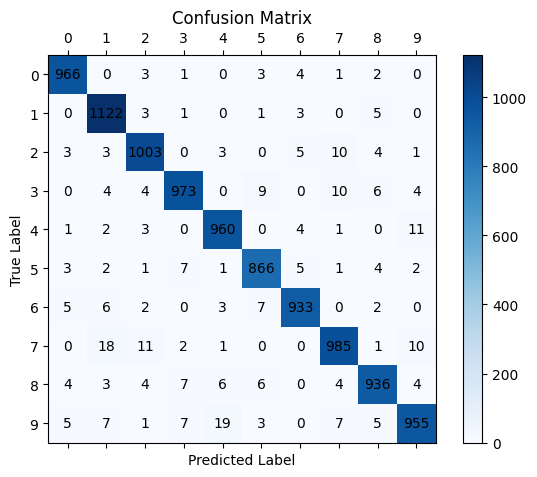

In [16]:
# Confusion-Matrix (s.o.)
cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(7, 5))
plt.matshow(cm, fignum=1, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Achsenbeschriftung 0-9
classes = np.arange(10)
plt.xticks(classes, classes)
plt.yticks(classes, classes)

# Zahlen in den Zellen anzeigen
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center')
        
plt.show()

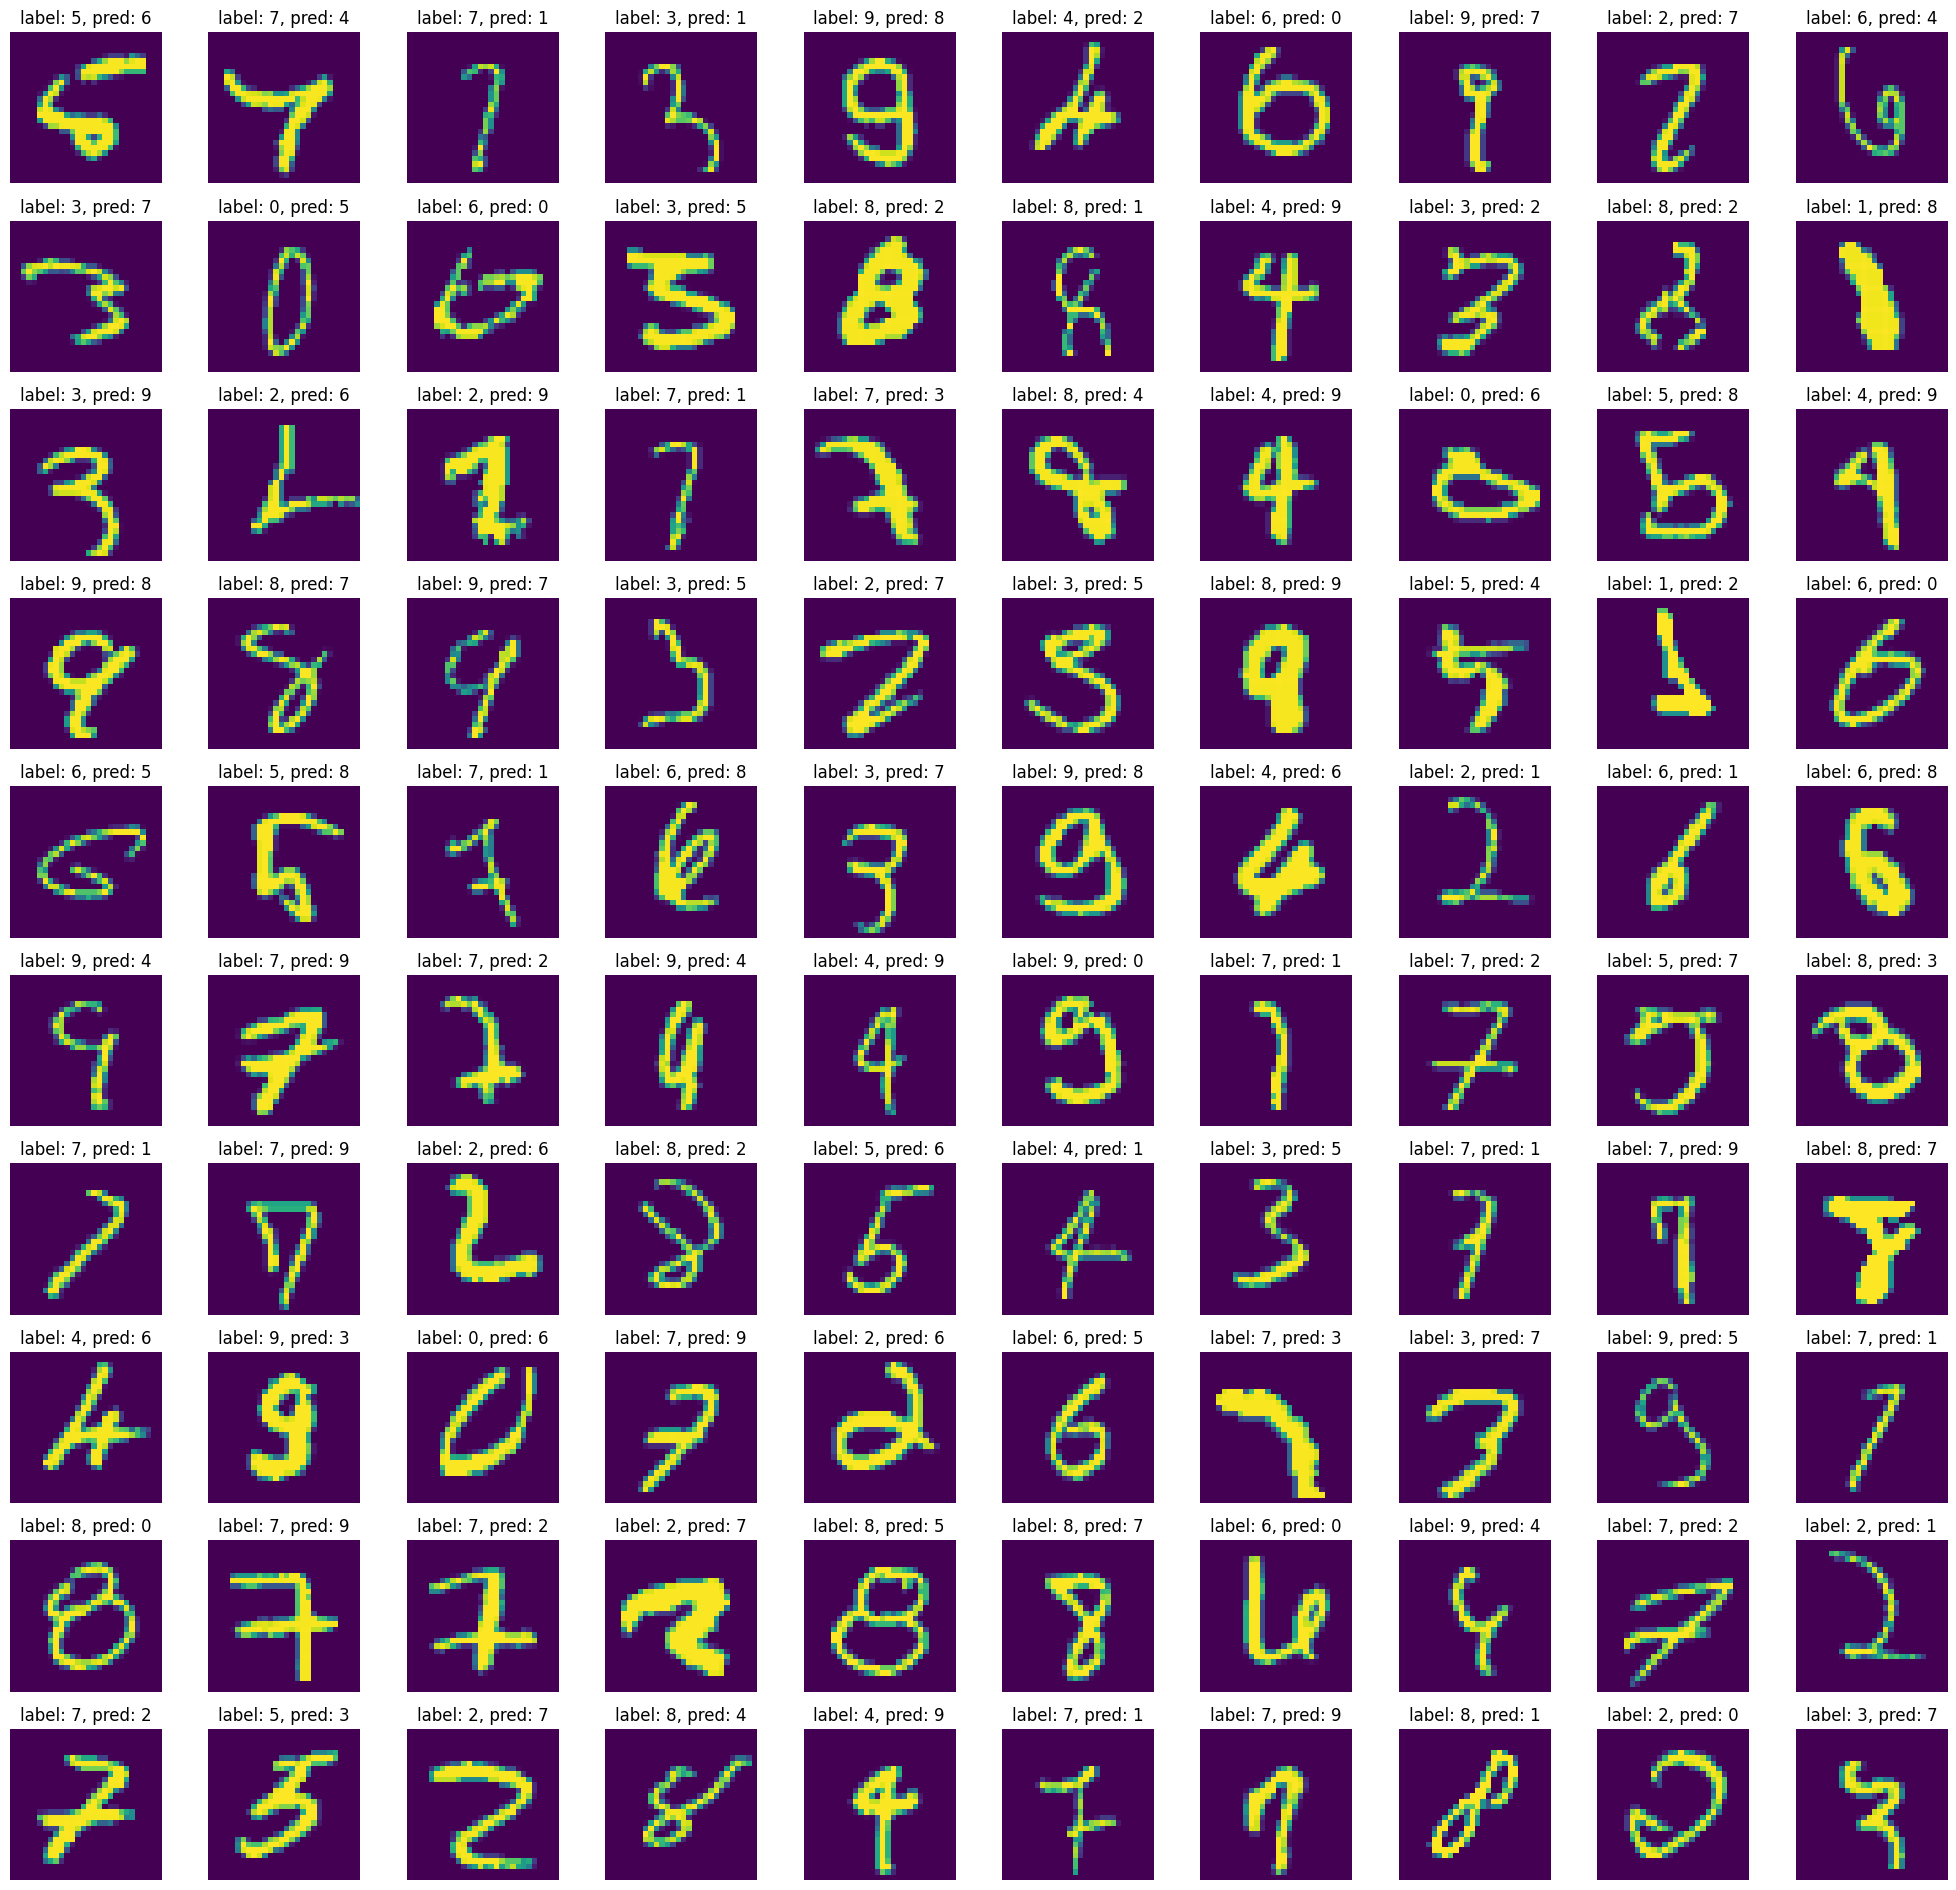

In [32]:
# ersten 100 falsch klassifizierten Labels
misclassified_idx = np.where(y_val != y_val_pred)[0]
num_errors = min(100, len(misclassified_idx))

plt.figure(figsize=(20, 20))

for i, idx in enumerate(misclassified_idx[:num_errors]):
    plt.subplot(10, 10, i+1)
    plt.imshow(x_val.iloc[idx].values.reshape(28, 28),)
    plt.title(f"label: {y_val.iloc[idx]}, pred: {y_val_pred[idx]}",fontsize=12)
    plt.axis('off')
    
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()